In [1]:
import sys
sys.path.insert(0, "../src/fg_removal_pipe")  # add Folder_2 path to search list
import diff_removal as bss
from Jybeam_2_K import TFromJyBeam
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np

base = '/home/ppxjf3/repos/Foreground_Removal_Pipeline/'

In [2]:
#open all fits images and make into numpy array

num = 4

bss_data = np.zeros([1024,1024,num])
for ii in range(0,num):

    fits_path = base + 'data/ZW3_BSS_000'+str(ii)+'-image.fits'

    hdul = fits.open(fits_path)

    img = np.squeeze(hdul[0].data)
    bss_data[:,:,ii] = img
    hdul.info()
    hdul.close()

Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0000-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0001-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0002-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0003-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   


In [12]:
#convert to K from Jy/beam
nu = np.array([106.0,106.1,106.2,106.3])
print(nu)
#beam size
bmaj = 0.0441365996677112
bmin = 0.032916727852457

bss_data_K = TFromJyBeam(bss_data, bmaj, bmin, nu)

[106.  106.1 106.2 106.3]


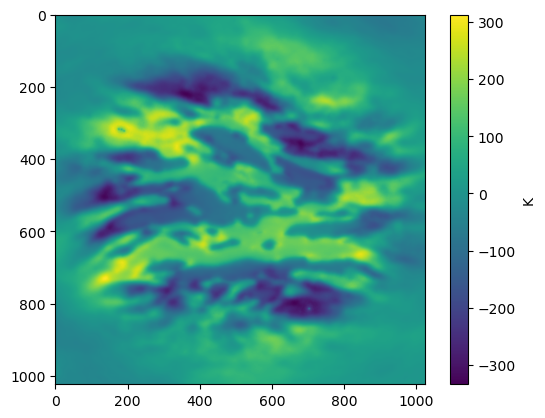

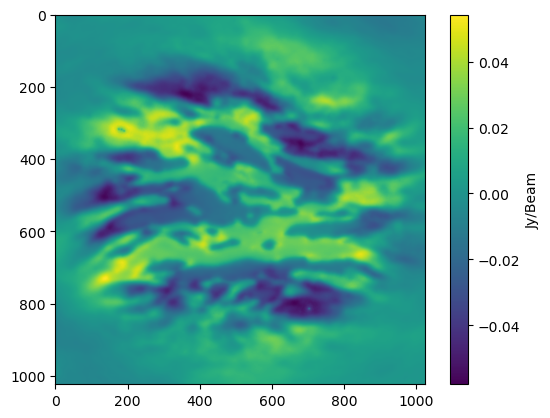

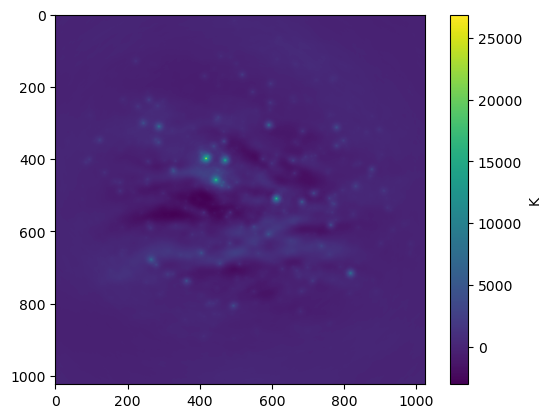

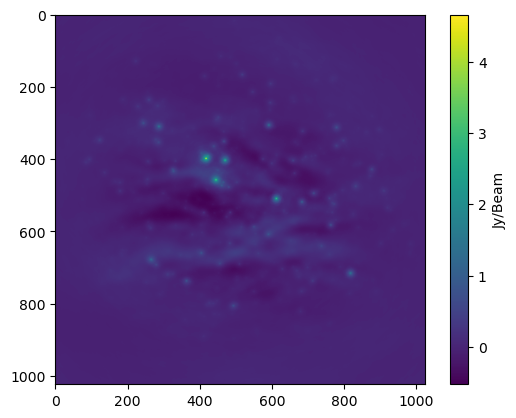

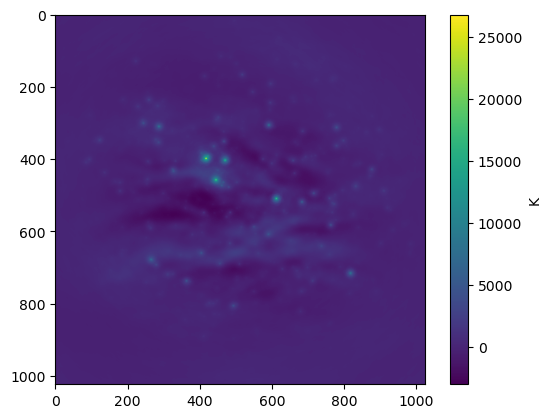

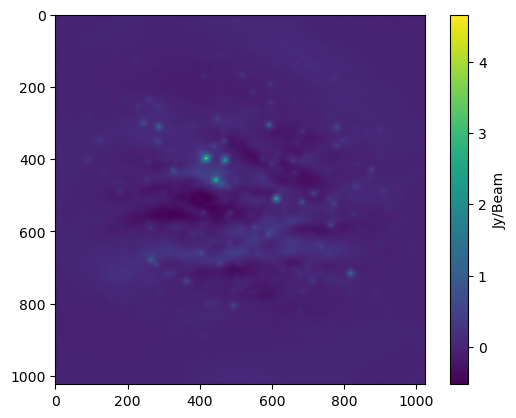

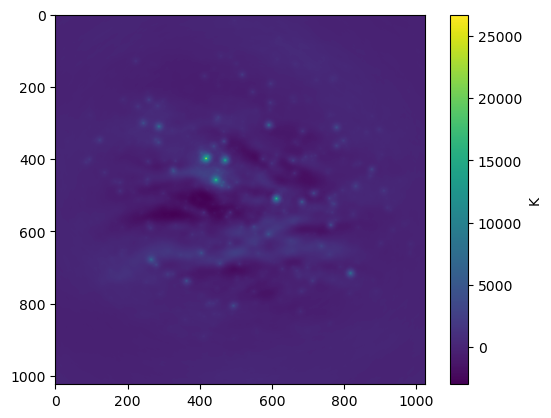

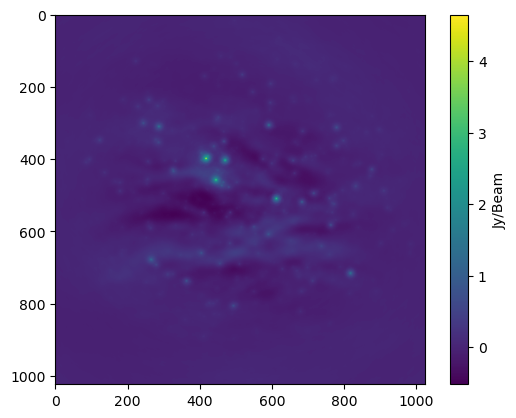

In [16]:
#look at images
for ii in range(0,num):
    plt.imshow(bss_data_K[:,:,ii])
    plt.colorbar(label='K')
    plt.show()
    plt.imshow(bss_data[:,:,ii])
    plt.colorbar(label='Jy/Beam')
    plt.show()

In [9]:
#cut to central 

mod, res = bss.fastica(bss_data, 4)
    

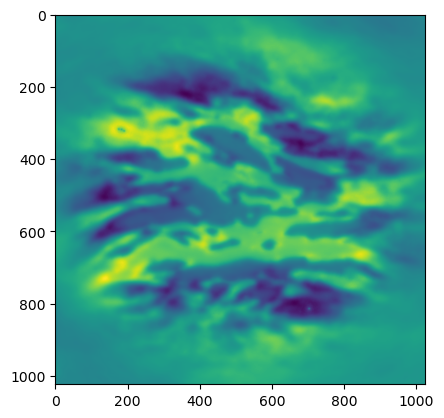

In [11]:
plt.imshow(mod[:,:,0])